# Step 2｜标签、主键与周度时间审计

## 目的

理解 Home Credit 2024 训练样本的主键、时间轴和标签分布，
为 Step 3 的时间切分与 Final OOT 锁定提供证据。

## 本阶段边界

- 只读取 `train_base.parquet`；
- 不连接任何特征表；
- 不构造或处理模型特征；
- 不划分 Train、Validation 或 Final OOT；
- 不训练模型；
- 不把 `target` 擅自解释为违约或 12 个月 PD。

## 最终输出

`reports/01_base_time_target_audit.md`

In [5]:
# Step 2.1.1：定义项目路径
from pathlib import Path
import pandas as pd

DATA_ROOT = Path(r"<HOME_CREDIT_DATA_ROOT>")
PROJECT_ROOT = Path(r"<PROJECT_ROOT>")

REPORTS_DIR = PROJECT_ROOT / "reports"

TRAIN_BASE_PATH = (
    DATA_ROOT
    / "parquet_files"
    / "train"
    / "train_base.parquet"
)

REPORT_PATH = (
    REPORTS_DIR
    / "01_base_time_target_audit.md"
)

# reports文件夹不存在时才创建
REPORTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# 先确认文件真实存在，避免路径写错后继续运行
if not TRAIN_BASE_PATH.is_file():
    raise FileNotFoundError(
        f"没有找到train_base文件：{TRAIN_BASE_PATH}"
    )

print("数据文件：", TRAIN_BASE_PATH)
print("项目目录：", PROJECT_ROOT)
print("报告目录：", REPORTS_DIR)
print("最终报告：", REPORT_PATH)
print("train_base是否存在：", TRAIN_BASE_PATH.is_file())

数据文件： <HOME_CREDIT_DATA_ROOT>\parquet_files\train\train_base.parquet
项目目录： <PROJECT_ROOT>
报告目录： <PROJECT_ROOT>\reports
最终报告： <PROJECT_ROOT>\reports\01_base_time_target_audit.md
train_base是否存在： True


In [6]:
# Step 2.1.2：读取Train base样本轴

base_columns = [
    "case_id",
    "date_decision",
    "WEEK_NUM",
    "MONTH",
    "target"
]

base = pd.read_parquet(
    TRAIN_BASE_PATH,
    columns=base_columns
)

print("读取完成")
print("数据形状：", base.shape)
print("字段：", base.columns.tolist())

print(
    "内存占用：",
    round(
        base.memory_usage(deep=True).sum()
        / 1024**2,
        2
    ),
    "MB"
)

print("\n字段类型：")
display(
    base.dtypes.to_frame("dtype")
)

print("\n前5行：")
display(
    base.head()
)

读取完成
数据形状： (1526659, 5)
字段： ['case_id', 'date_decision', 'WEEK_NUM', 'MONTH', 'target']
内存占用： 132.49 MB

字段类型：


,dtype
case_id,int64
date_decision,object
WEEK_NUM,int64
MONTH,int64
target,int64



前5行：


,case_id,date_decision,WEEK_NUM,MONTH,target
0,0,2019-01-03,0,201901,0
1,1,2019-01-03,0,201901,0
2,2,2019-01-04,0,201901,0
3,3,2019-01-03,0,201901,0
4,4,2019-01-04,0,201901,1


In [7]:
# Step 2.2：审计case_id
case_id_audit = pd.Series({
    "总行数": len(base),
    "case_id缺失数": base["case_id"].isna().sum(),
    "case_id唯一值数": base["case_id"].nunique(),
    "重复涉及的全部行数": base["case_id"]
        .duplicated(keep=False)
        .sum(),
    "超出首次出现的重复行数": base["case_id"]
        .duplicated()
        .sum()
})

display(case_id_audit.to_frame("结果"))

,结果
总行数,1526659
case_id缺失数,0
case_id唯一值数,1526659
重复涉及的全部行数,0
超出首次出现的重复行数,0


In [12]:
# Step 2.3：审计时间字段范围（date_decision、WEEK_NUM和MONTH）

date_decision_parsed = pd.to_datetime(
    base["date_decision"],
    errors="coerce" #?
)

date_parse_failures = (
    base["date_decision"].notna()
    & date_decision_parsed.isna()
).sum()

time_audit = pd.DataFrame({
    "字段": [
        "date_decision",
        "WEEK_NUM",
        "MONTH"
    ],
    "缺失数": [
        date_decision_parsed.isna().sum(),
        base["WEEK_NUM"].isna().sum(),
        base["MONTH"].isna().sum()
    ],
    "最小值": [
        date_decision_parsed.min(),
        base["WEEK_NUM"].min(),
        base["MONTH"].min()
    ],
    "最大值": [
        date_decision_parsed.max(),
        base["WEEK_NUM"].max(),
        base["MONTH"].max()
    ],
    "唯一值数": [
        date_decision_parsed.nunique(),
        base["WEEK_NUM"].nunique(),
        base["MONTH"].nunique()
    ],
})

display(time_audit)

print(
    "无法解析的非空日期数：",
    date_parse_failures
)

,字段,缺失数,最小值,最大值,唯一值数
0,date_decision,0,2019-01-01 00:00:00,2020-10-05 00:00:00,644
1,WEEK_NUM,0,0,91,92
2,MONTH,0,201901,202010,22


无法解析的非空日期数： 0


In [14]:
# Step 2.4：统计每周样本量、事件数和事件率
target_values = sorted(
    base["target"]
    .dropna()
    .unique()
    .tolist()
)

print("target取值：", target_values)

if not set(target_values).issubset({0,1}):
    raise ValueError(
        f"target不是标准二元标签：{target_values}"
    )

weekly_summary = (
    base.groupby("WEEK_NUM", as_index = False)
    .agg(
        start_date = ("date_decision", "min"),
        end_date = ("date_decision", "max"),
        sample_count=("case_id", "size"),
        event_count=("target", "sum"),
        event_rate=("target", "mean")  #?
    )
)

weekly_summary["non_event_count"] = (
    weekly_summary["sample_count"]
    - weekly_summary["event_count"]
)

weekly_summary = weekly_summary[
    [
        "WEEK_NUM",
        "start_date",
        "end_date",
        "sample_count",
        "event_count",
        "non_event_count",
        "event_rate"
    ]
]

print("周数：", len(weekly_summary))

print("\n前5周：")
display(weekly_summary.head())

print("\n最后5周：")
display(weekly_summary.tail())

target取值： [0, 1]
周数： 92

前5周：


,WEEK_NUM,start_date,end_date,sample_count,event_count,non_event_count,event_rate
0,0,2019-01-01,2019-01-07,16735,400,16335,0.023902
1,1,2019-01-08,2019-01-14,18841,472,18369,0.025052
2,2,2019-01-15,2019-01-21,17476,465,17011,0.026608
3,3,2019-01-22,2019-01-28,16108,419,15689,0.026012
4,4,2019-01-29,2019-02-04,14309,404,13905,0.028234



最后5周：


,WEEK_NUM,start_date,end_date,sample_count,event_count,non_event_count,event_rate
87,87,2020-09-01,2020-09-07,17886,329,17557,0.018394
88,88,2020-09-08,2020-09-14,14234,265,13969,0.018617
89,89,2020-09-15,2020-09-21,13600,309,13291,0.022721
90,90,2020-09-22,2020-09-28,12103,330,11773,0.027266
91,91,2020-09-29,2020-10-05,12674,288,12386,0.022724


In [18]:
# Step 2.5：检查缺失周、缺失标签和单类别周
observed_weeks = set(
    weekly_summary["WEEK_NUM"]
)

expected_weeks = set(
    range(
        weekly_summary["WEEK_NUM"].min(),
        weekly_summary["WEEK_NUM"].max() + 1
    )
)

missing_weeks = sorted(
    expected_weeks - observed_weeks
)

target_missing_count = (
    base["target"].isna().sum()
)

single_class_weeks = weekly_summary[
    (weekly_summary["event_count"] == 0)
    | (weekly_summary["non_event_count"] == 0)
]

print("缺失周：", missing_weeks)
print("target缺失数：", target_missing_count)
print("单类别周数：", len(single_class_weeks))

display(single_class_weeks)

缺失周： []
target缺失数： 0
单类别周数： 0


,WEEK_NUM,start_date,end_date,sample_count,event_count,non_event_count,event_rate


,count,mean,std,min,5%,25%,50%,75%,95%,max
sample_count,92.0,16594.119565,7004.197623,825.000000,4055.500000,12542.000000,17088.500000,21337.500000,26464.500000,35920.000000
event_count,92.0,521.673913,278.658999,21.000000,89.700000,306.750000,513.500000,802.500000,936.900000,1136.000000
event_rate,92.0,0.030110,0.008309,0.017722,0.020152,0.023846,0.027942,0.035085,0.046881,0.052144


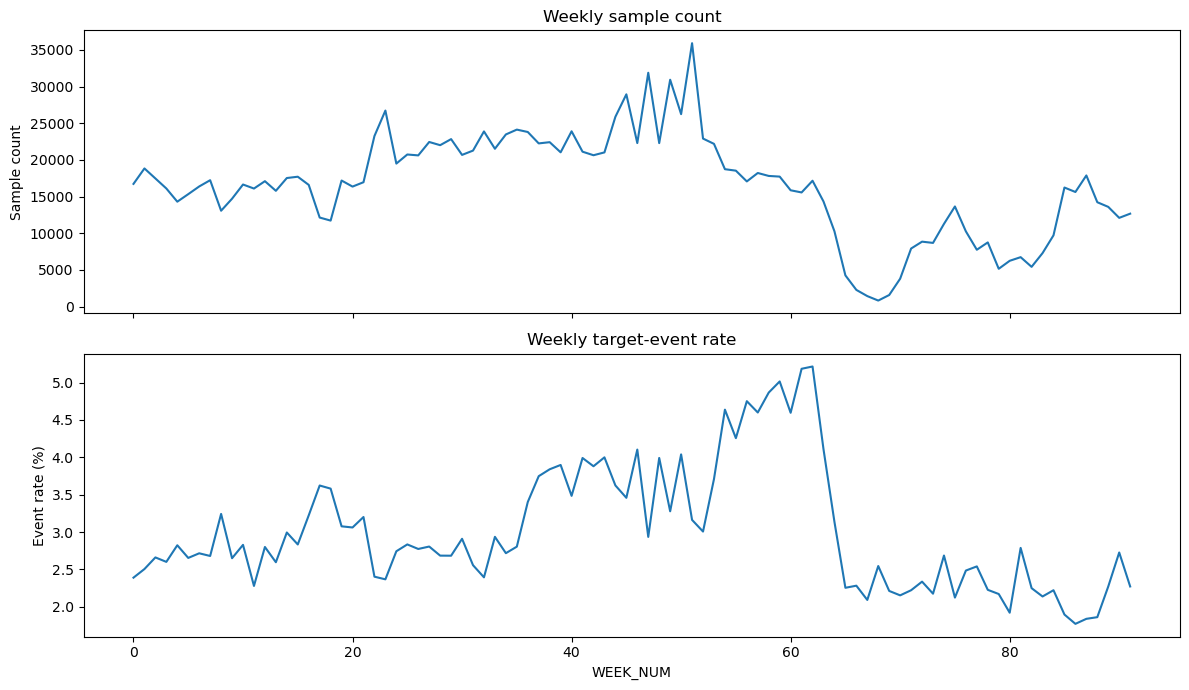

In [21]:
# Step 2.5.2：观察周度样本量和事件率变化
import matplotlib.pyplot as plt

## 从每周汇总表 weekly_summary 中，选出每周样本数、事件数、事件率这 3 个指标，计算它们的样本数、平均值、标准差、最小值、5%、25%、50%、75%、95%分位数和最大值，然后转置结果，并保存到 weekly_distribution。
weekly_distribution = weekly_summary[
    [
        "sample_count",
        "event_count",
        "event_rate"
    ]
].describe(
    percentiles = [0.05, 0.25, 0.5, 0.75, 0.95]
).T

display(weekly_distribution)

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(12, 7),
    sharex=True
)

axes[0].plot(
    weekly_summary["WEEK_NUM"],
    weekly_summary["sample_count"]
)

axes[0].set_ylabel("Sample count")
axes[0].set_title("Weekly sample count")

axes[1].plot(
    weekly_summary["WEEK_NUM"],
    weekly_summary["event_rate"] * 100
)

axes[1].set_xlabel("WEEK_NUM")
axes[1].set_ylabel("Event rate (%)")
axes[1].set_title("Weekly target-event rate")

plt.tight_layout()
plt.show()

In [22]:
# Step 2.5.3：定位周度极值和最大环比变化
weekly_changes = weekly_summary.copy()

weekly_changes["sample_change_pct"] = (    #每一周的 sample_count 相比上一周变化了百分之多少。
    weekly_changes["sample_count"]
    .pct_change()    #.pct_change() 计算“相对上一行的变化率”，公式：(当前值 - 上一期值) / 上一期值
    * 100    #* 100 转成百分数
)

weekly_changes["event_rate_change_pp"] = (    #本周 event_rate 相比上一周变化了多少“百分点（percentage points, pp）”
    weekly_changes["event_rate"]
    .diff()    #计算“当前值 - 上一行值”
    * 100
)

weekly_changes["abs_sample_change_pct"] = (
    weekly_changes["sample_change_pct"].abs()
)

weekly_changes["abs_event_rate_change_pp"] = (
    weekly_changes["event_rate_change_pp"].abs()
)

extreme_indexes = sorted(set([
    weekly_summary["sample_count"].idxmin(),
    weekly_summary["sample_count"].idxmax(),
    weekly_summary["event_rate"].idxmin(),
    weekly_summary["event_rate"].idxmax()
]))

print("周度极值：")
display(
    weekly_changes.loc[
        extreme_indexes,
        [
            "WEEK_NUM",
            "start_date",
            "end_date",
            "sample_count",
            "event_count",
            "event_rate"
        ]
    ]
)

print("样本量环比变化最大的5周：")
display(
    weekly_changes.nlargest(
        5,
        "abs_sample_change_pct"
    )[
        [
            "WEEK_NUM",
            "sample_count",
            "sample_change_pct"
        ]
    ]
)

print("事件率变化最大的5周：")
display(
    weekly_changes.nlargest(
        5,
        "abs_event_rate_change_pp"
    )[
        [
            "WEEK_NUM",
            "event_rate",
            "event_rate_change_pp"
        ]
    ]
)

周度极值：


,WEEK_NUM,start_date,end_date,sample_count,event_count,event_rate
51,51,2019-12-24,2019-12-30,35920,1136,0.031626
62,62,2020-03-10,2020-03-16,17164,895,0.052144
68,68,2020-04-21,2020-04-27,825,21,0.025455
86,86,2020-08-25,2020-08-31,15630,277,0.017722


样本量环比变化最大的5周：


,WEEK_NUM,sample_count,sample_change_pct
70,70,3808,140.707965
71,71,7921,108.009454
69,69,1582,91.757576
85,85,16239,67.050715
65,65,4258,-58.531360


事件率变化最大的5周：


,WEEK_NUM,event_rate,event_rate_change_pp
47,47,0.029353,-1.168050
63,63,0.041083,-1.106151
48,48,0.039914,1.056116
64,64,0.031360,-0.972295
54,54,0.046371,0.928930


## Step 2.6｜官方target语义与标签成熟度

### 1. 官方语义

Kaggle官方数据说明中：

- `case_id`是每个信用案件的唯一标识；
- `target`是在经过一段时间后，根据客户是否在该笔信用案件（贷款）上发生违约而确定的二元标签。

官方来源：[Home Credit - Credit Risk Model Stability](https://www.kaggle.com/competitions/home-credit-credit-risk-model-stability/data)

因此，本项目将：

- `target = 1`解释为该笔信用案件发生了数据集定义的违约事件；
- `target = 0`解释为该笔信用案件未发生该事件。

### 2. 不能扩大的解释

公开说明没有披露：

- 具体表现窗口长度；
- 逾期天数阈值；
- 是否采用90+ DPD；
- 是否对应12个月观察期；
- 核销、重组等违约认定规则。

因此，本项目不能把`target`进一步声称为：

- 12个月PD标签；
- 90+ DPD违约标签；
- 符合某一银行监管口径的违约标签。

### 3. 标签成熟度

本地训练数据中：

- 1,526,659个样本均有target；
- 92周均不存在标签缺失；
- 每周都同时包含target=0和target=1。

这说明公开训练集的标签在数据层面完整可用。

但是，由于官方没有披露具体表现窗口及标签截断日期，
本项目无法独立验证每个样本是否经历了完全一致的标签成熟期。

因此，后续将其视为官方提供的已观察二元结果使用，
同时把“标签成熟过程无法独立验证”记录为数据限制。

In [ ]:
# Step 2.7：生成reports/01_base_time_target_audit.md
def dataframe_to_markdown(dataframe):
    def escape(value):
        return (
            str(value)
            .replace("|", "\\|")
            .replace("\n", " ")
        )
        
    headers = [
        escape(column)
        for column in dataframe.columns
    ]

    lines = [
        "| " + " | ".join(headers) + " |",
        "| " + " | ".join(
            ["---"] * len(headers)
        ) + " |"
    ]

    